In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dict_currencies = {"RUR": 1, "AZN": 58.82, "BYR": 30.54, "EUR": 105.25, "GEL": 35.56, "KGS": 1.16, "KZT": 0.2, "UAH": 2.42, "USD": 100, "UZS": 0.0078}
df = pd.read_csv("C:\\Users\\User\\OneDrive\\Документы\\GitHub\\hh-analytics\\vacancies.csv") 
df = df.drop_duplicates(subset='id', keep='first').set_index('id')

def combine_salaries(row):
    if not np.isnan(row['salary_from']) and not np.isnan(row['salary_to']):
        return (row['salary_from'] + row['salary_to']) / 2
    elif not np.isnan(row['salary_from']):
        return row['salary_from']
    elif not np.isnan(row['salary_to']):
        return row['salary_to']
    else:
        return None

def short_name_experiemnt(df):
    if df['experience_name'] == 'Нет опыта':
        return 0
    elif df['experience_name'] == 'От 1 года до 3 лет':
        return 1
    elif df['experience_name'] == 'От 3 до 6 лет':
        return 2
    elif df['experience_name'] == 'Более 6 лет':
        return 3
    else:
        return None

df['salary_combined'] = df.apply(combine_salaries, axis=1)
df['short_name_experience'] = df.apply(short_name_experiemnt, axis=1)
df['published_date'] = df['published_at'].str[:10]
df['published_date'] = pd.to_datetime(df['published_date'])
df['salary_in_rub'] = df.apply(lambda row: row['salary_combined'] * dict_currencies.get(row['currency'], None) if pd.notnull(row['salary_combined']) and row['currency'] in dict_currencies else None, axis=1)

df

,has_test,area_name,salary_from,salary_to,currency,published_at,snippet_requirement,snippet_responsibility,experience_name,employment_name,alternate_url,salary_combined,short_name_experience,published_date,salary_in_rub
id,,,,,,,,,,,,,,,
109034206,False,Москва,130000.0,130000.0,RUR,2024-10-22T09:37:32+0300,Знание инструментов мониторинга и <highlightte...,Выверка списков обучающихся совместно с отдело...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/109034206,130000.0,1,2024-10-22,130000.0
110036611,True,Санкт-Петербург,80000.0,180000.0,RUR,2024-11-04T09:57:06+0300,...с <highlighttext>аналитиками</highlighttext...,"Помощь в постановке задач, планировании, оценк...",От 3 до 6 лет,Полная занятость,https://hh.ru/vacancy/110036611,130000.0,2,2024-11-04,130000.0
109139832,False,Москва,20000.0,25000.0,RUR,2024-10-23T13:12:51+0300,"Опыт работы на Озон от 1,5 лет. Знание сервисо...",Формирование цен в зависимости от остатков и с...,От 1 года до 3 лет,Частичная занятость,https://hh.ru/vacancy/109139832,22500.0,1,2024-10-23,22500.0
109227060,False,Москва,100000.0,110000.0,RUR,2024-11-05T14:37:12+0300,"Опыт работы в программе 1С (планы закупок, зак...",Ведение базы <highlighttext>данных</highlightt...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/109227060,105000.0,1,2024-11-05,105000.0
109962974,False,Санкт-Петербург,NaN,60000.0,RUR,2024-11-02T14:10:21+0300,"Знание нотаций UML (минимально Sequence, State...",Use Cases / User story.,Нет опыта,Стажировка,https://hh.ru/vacancy/109962974,60000.0,0,2024-11-02,60000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111936432,False,Артем,80000.0,NaN,RUR,2024-11-27T07:56:36+0300,Средне специальное (инженерное) или высшее обр...,Контроль наличия комплектующих на виртуальных ...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/111936432,80000.0,1,2024-11-27,80000.0
109807065,False,Москва,80000.0,NaN,RUR,2024-11-28T05:52:49+0300,...на <highlighttext>данных</highlighttext> по...,Выстраивание стратегии ценообразования на осно...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/109807065,80000.0,1,2024-11-28,80000.0
108277756,False,Санкт-Петербург,NaN,NaN,NaN,2024-11-11T14:00:54+0300,"Опытный пользователь MS Office, 1С СЭД. Опрятн...",Осуществление административной и хозяйственной...,Нет опыта,Полная занятость,https://hh.ru/vacancy/108277756,NaN,0,2024-11-11,NaN


In [4]:
df4 = pd.read_csv("C:\\Users\\User\\OneDrive\\Документы\\GitHub\\hh-analytics\\vacancies_updated.csv")
df4

,id,has_test,area_name,salary_from,salary_to,currency,published_at,snippet_requirement,snippet_responsibility,experience_name,employment_name,alternate_url,salary_combined,short_name_experience,published_date,salary_in_rub
0,109034206,False,Москва,130000.0,130000.0,RUR,2024-10-22T09:37:32+0300,Знание инструментов мониторинга и <highlightte...,Выверка списков обучающихся совместно с отдело...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/109034206,130000.0,1,2024-10-22,130000.0
1,110036611,True,Санкт-Петербург,80000.0,180000.0,RUR,2024-11-04T09:57:06+0300,...с <highlighttext>аналитиками</highlighttext...,"Помощь в постановке задач, планировании, оценк...",От 3 до 6 лет,Полная занятость,https://hh.ru/vacancy/110036611,130000.0,2,2024-11-04,130000.0
2,109139832,False,Москва,20000.0,25000.0,RUR,2024-10-23T13:12:51+0300,"Опыт работы на Озон от 1,5 лет. Знание сервисо...",Формирование цен в зависимости от остатков и с...,От 1 года до 3 лет,Частичная занятость,https://hh.ru/vacancy/109139832,22500.0,1,2024-10-23,22500.0
3,109227060,False,Москва,100000.0,110000.0,RUR,2024-11-05T14:37:12+0300,"Опыт работы в программе 1С (планы закупок, зак...",Ведение базы <highlighttext>данных</highlightt...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/109227060,105000.0,1,2024-11-05,105000.0
4,109962974,False,Санкт-Петербург,NaN,60000.0,RUR,2024-11-02T14:10:21+0300,"Знание нотаций UML (минимально Sequence, State...",Use Cases / User story.,Нет опыта,Стажировка,https://hh.ru/vacancy/109962974,60000.0,0,2024-11-02,60000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6568,111936432,False,Артем,80000.0,NaN,RUR,2024-11-27T07:56:36+0300,Средне специальное (инженерное) или высшее обр...,Контроль наличия комплектующих на виртуальных ...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/111936432,80000.0,1,2024-11-27,80000.0
6569,109807065,False,Москва,80000.0,NaN,RUR,2024-11-28T05:52:49+0300,...на <highlighttext>данных</highlighttext> по...,Выстраивание стратегии ценообразования на осно...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/109807065,80000.0,1,2024-11-28,80000.0
6570,108277756,False,Санкт-Петербург,NaN,NaN,NaN,2024-11-11T14:00:54+0300,"Опытный пользователь MS Office, 1С СЭД. Опрятн...",Осуществление административной и хозяйственной...,Нет опыта,Полная занятость,https://hh.ru/vacancy/108277756,NaN,0,2024-11-11,NaN
6571,110958967,False,Москва,NaN,NaN,NaN,2024-11-14T11:39:00+0300,Понимание результатов хозяйственной деятельнос...,Взаимодействие с банками с целью своевременной...,От 1 года до 3 лет,Полная занятость,https://hh.ru/vacancy/110958967,NaN,1,2024-11-14,NaN


**Оценка нормальности распределения зарплат в каждой категории опыта работы**


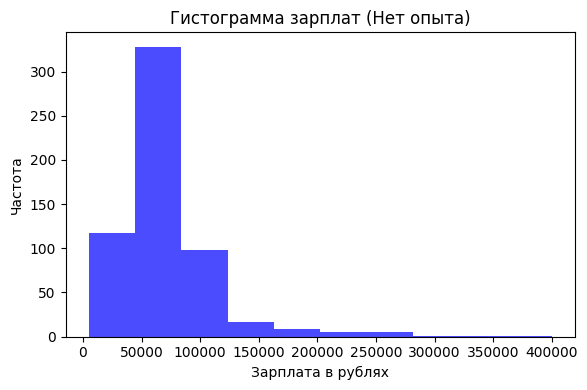

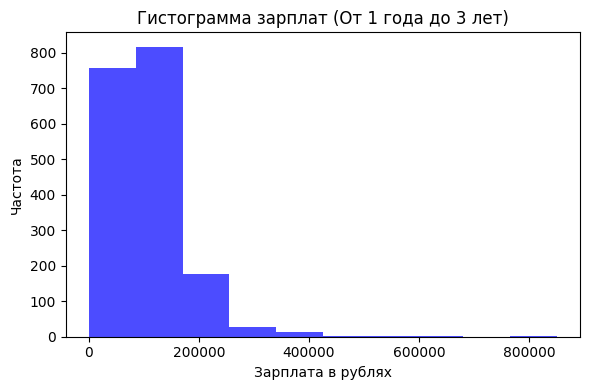

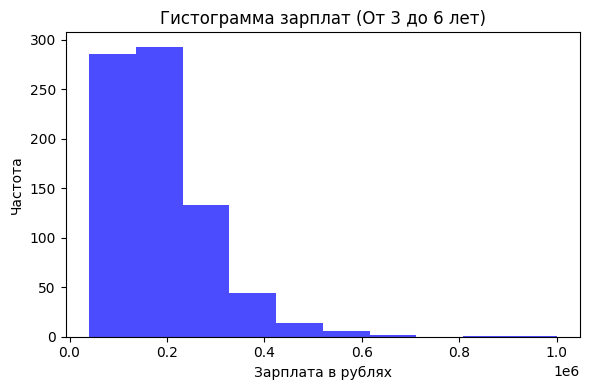

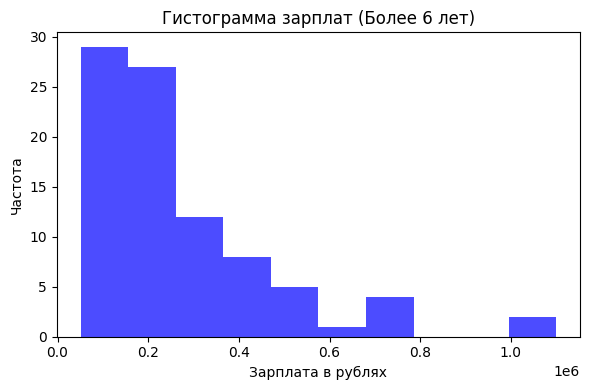

In [10]:
def visualize_salary_groups(df):
    experience_labels = {0: 'Нет опыта', 1: 'От 1 года до 3 лет', 2: 'От 3 до 6 лет', 3: 'Более 6 лет'}    
    for experience, label in experience_labels.items():
        group = df[df['short_name_experience'] == experience]['salary_in_rub']
        plt.figure(figsize=(6, 4))
        plt.hist(group, bins=10, color='blue', alpha=0.7)
        plt.title(f'Гистограмма зарплат ({label})')
        plt.xlabel('Зарплата в рублях')
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()

visualize_salary_groups(df)

**Тест Шапиро-Уилка**

In [11]:
from scipy import stats
from scipy.stats import shapiro
df = df.dropna(subset=['salary_in_rub'])  
for group in range(4):
    group_data = df[df['short_name_experience'] == group][['salary_in_rub', 'short_name_experience']]
    stat, p_value = stats.shapiro(group_data)
    print(group, stat, p_value)    

0 0.747532308516161 8.127604039355367e-39
1 0.7670499769253778 1.0806114341740419e-57
2 0.7781651520630952 1.1117358039347381e-41
3 0.7180700149542171 5.4893500434142513e-17


p-value < 0.05 отвергаем нулевую гипотезу. Данные не распределены нормально 

**Критерий Краскела-Уолиса**


In [12]:
def kruskal_test(df):
    df = df.dropna(subset=['salary_in_rub'])
    group0 = df[df['short_name_experience'] == 0]['salary_in_rub']
    group1 = df[df['short_name_experience'] == 1]['salary_in_rub']
    group2 = df[df['short_name_experience'] == 2]['salary_in_rub']
    group3 = df[df['short_name_experience'] == 3]['salary_in_rub']
    h_stat, p_value = stats.kruskal(group0, group1, group2, group3)
    print(f'H-статистика: {h_stat}')
    print(f'p-value: {p_value}')   
kruskal_test(df)

H-статистика: 992.3226776670159
p-value: 8.328598481894749e-215


 p-value < 0.05  отвергаем нулевую гипотезу, средние и медианы не равны. Опыт влияет на размер зарплаты.

**Тест Данна**

In [13]:
import scikit_posthocs as sp

result = sp.posthoc_dunn([df[df['short_name_experience'] == 0]['salary_in_rub'], df[df['short_name_experience'] == 1]['salary_in_rub'], df[df['short_name_experience'] == 2]['salary_in_rub'], df[df['short_name_experience'] == 3]['salary_in_rub']])
result

,1,2,3,4
1,1.000000e+00,8.696199e-59,2.137836e-193,1.030557e-60
2,8.696199e-59,1.000000e+00,3.651893e-88,3.118666e-24
3,2.137836e-193,3.651893e-88,1.000000e+00,2.327928e-02
4,1.030557e-60,3.118666e-24,2.327928e-02,1.000000e+00


Группы статистически сильно отличаются друг от друга. Между 3-й и 4-й группой практически нет отличий, так как p=0.02 < a=0.05

**Зарплатные данные по городам в вакансиях с опытом работы 3–6 лет** 


In [14]:
filtered_df = df[df['short_name_experience'] == 2][['area_name', 'salary_in_rub']]
mean_regions = filtered_df.groupby('area_name')['salary_in_rub'].mean().rename('mean_salary')
median_regions = filtered_df.groupby('area_name')['salary_in_rub'].median().rename('median_salary')
result_df = pd.DataFrame({'mean_salary': mean_regions, 'median_salary': median_regions})
result_df

,mean_salary,median_salary
area_name,,
Актобе,160000.0,160000.0
Александров,152366.5,152366.5
Алматы,112520.0,102500.0
Альметьевск,300000.0,300000.0
Арзамас,107525.0,107525.0
...,...,...
Шымкент,70000.0,70000.0
Южно-Сахалинск,105000.0,105000.0
Якутск,118000.0,118000.0


**Анализ временного ряда для группы 3-6 лет опыта работы**

In [57]:
df_2 = df[df['short_name_experience']== 2][['salary_in_rub']]
df_2.index = df[df['short_name_experience'] == 2]['published_date'].values
df_2 = df_2.dropna()
df_2 = df_2.groupby(level=0).median()
df_2 = pd.Series(df_2.iloc[:, 0])
df_2 = df_2.resample('D').median()  
df_2 = df_2.interpolate()

df_2.head()

2024-10-08    215000.000000
2024-10-09    200000.000000
2024-10-10    220000.000000
2024-10-11    175000.000000
2024-10-12    168333.333333
Freq: D, Name: salary_in_rub, dtype: float64

In [58]:
df_2.describe()

count        52.000000
mean     174841.567308
std       46730.343592
min      100000.000000
25%      150000.000000
50%      168416.666667
75%      200000.000000
max      357500.000000
Name: salary_in_rub, dtype: float64

In [59]:
df_2.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 52 entries, 2024-10-08 to 2024-11-28
Freq: D
Series name: salary_in_rub
Non-Null Count  Dtype  
--------------  -----  
52 non-null     float64
dtypes: float64(1)
memory usage: 832.0 bytes


**Линейный тренд**

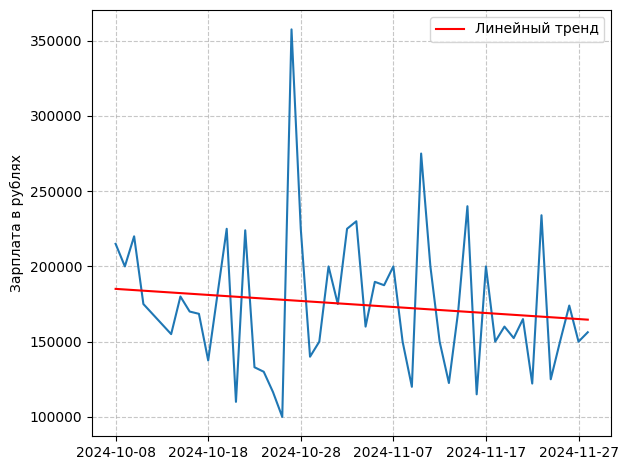

In [60]:
x = (df_2.index - df_2.index[0]).days  
y = df_2.values.flatten() 
coeffs = np.polyfit(x, y, deg=1) 
trend_line = np.polyval(coeffs, x)
plt.plot(df_2.index, y)
plt.plot(df_2.index, trend_line, color='red', label='Линейный тренд')
plt.xticks(df_2.index[::10], ha='center')  
plt.ylabel('Зарплата в рублях')
plt.grid(True, linestyle='--', alpha=0.7)  
plt.legend()
plt.tight_layout()  
plt.show()


**Тесты на стационарность**

**Тест Дики-Фуллера**

In [61]:
from statsmodels.tsa.stattools import adfuller
result_adf = adfuller(df_2)
print('ADF Statistic: %f' % result_adf[0])
print('p-value: %f' % result_adf[1])
print('Critical Values:')
for key, value in result_adf[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.242918
p-value: 0.000000
Critical Values:
	1%: -3.568
	5%: -2.921
	10%: -2.599


*Ряд стационарен, так как p-value < 0.05*

**Тест KPSS**

In [62]:
from statsmodels.tsa.stattools import kpss
import warnings 
warnings.simplefilter("ignore", category=UserWarning) 
result_kpss = kpss(df_2)
print('KPSS Statistic: %f' % result_kpss[0])
print('p-value: %f' % result_kpss[1])
print('Critical Values:')
for key, value in result_kpss[3].items():  
    print('\t%s: %.3f' % (key, value))
  

KPSS Statistic: 0.211711
p-value: 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


*Ряд стацционарен, так как p-value > 0.05*

**Автокорреляция (ACF)**

Значения автокорреляции (ACF): [ 1.         -0.10073149 -0.17574851 -0.07040989  0.00241571  0.17528272
 -0.07046114  0.10620515  0.06104265 -0.06615059 -0.0725549   0.00257069
 -0.04322761 -0.08252189  0.16070971 -0.07285006 -0.18156464 -0.13699988
  0.04477908  0.18913589 -0.1837613 ]


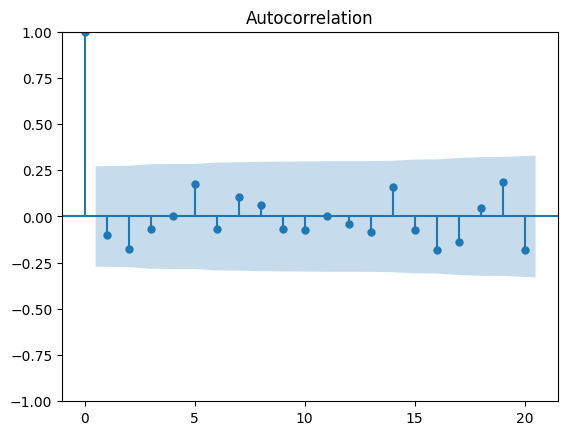

In [63]:
from statsmodels.graphics import tsaplots
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm
acf_values = acf(df_2, nlags=20)  
print('Значения автокорреляции (ACF):', acf_values)
fig = tsaplots.plot_acf(df_2, lags=20)
plt.show()

**Частичная автокорреляция (PACF)**

Значения PACF: [ 1.         -0.10270662 -0.19538818 -0.12318128 -0.06346706  0.15733891
 -0.05418249  0.1872332   0.1315393   0.00607114 -0.08338451 -0.00206652
 -0.1898573  -0.22132282  0.15664673 -0.14737106 -0.30771305 -0.27761613
 -0.09799812  0.11089867 -0.23704879]


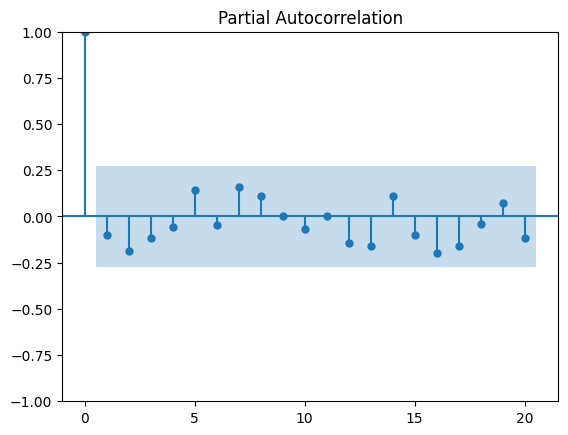

In [64]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

pacf_values = pacf(df_2, nlags=20)
print('Значения PACF:', pacf_values)
plot_pacf(df_2, lags=20)
plt.show()


*Значимого коэффициента автокорреляции не обнаружено*

In [89]:
# Check for missing dates
full_date_range = pd.date_range(start=df_2.index.min(), end=df_2.index.max(), freq='D')  # Daily frequency
missing_dates = full_date_range.difference(df_2.index)

print("Missing Dates:\n", missing_dates)

Missing Dates:
 DatetimeIndex([], dtype='datetime64[ns]', freq='D')


**Модель SARIMA**

In [90]:
from skforecast.recursive import ForecasterSarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [91]:
model = SARIMAX(endog = df_2, order = (1, 0, 1), seasonal_order = (3, 1, 3, 7))
model_res = model.fit(disp=0)
model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                         
=================================================================================================
Dep. Variable:                             salary_in_rub   No. Observations:                   52
Model:             SARIMAX(1, 0, 1)x(3, 1, [1, 2, 3], 7)   Log Likelihood                -555.011
Date:                                   Mon, 03 Feb 2025   AIC                           1128.023
Time:                                           19:36:39   BIC                           1144.283
Sample:                                       10-08-2024   HQIC                          1134.084
                                            - 11-28-2024                                         
Covariance Type:                                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9810      0.168      5.845      0.000       0.652       1.310
ma.L1         -0.8995      0.141     -6.358      0.000      -1.177      -0.622
ar.S.L7        0.9096      7.505      0.121      0.904     -13.800      15.620
ar.S.L14      -0.6436      6.219     -0.103      0.918     -12.832      11.545
ar.S.L21       0.0065      1.969      0.003      0.997      -3.853       3.866
ma.S.L7       -1.5567      7.328     -0.212      0.832     -15.919      12.806
ma.S.L14       1.2836     11.326      0.113      0.910     -20.916      23.483
ma.S.L21      -0.5588      2.447     -0.228      0.819      -5.355       4.237
sigma2      3.908e+09   2.89e-09   1.35e+18      0.000    3.91e+09    3.91e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 9.22
Prob(Q):                              0.73   Prob(JB):                         0.01
Heteroskedasticity (H):               0.48   Skew:                             0.94
Prob(H) (two-sided):                  0.17   Kurtosis:                         4.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.72e+34. Standard errors may be unstable.
"""

In [92]:
predictions_statsmodels = model_res.get_forecast(steps=len(df_2)).predicted_mean
predictions_statsmodels.name = 'predictions_statsmodels'
display(predictions_statsmodels.head())

2024-11-29    167540.452847
2024-11-30    170112.745696
2024-12-01    168312.279156
2024-12-02    148416.500203
2024-12-03    184129.098284
Freq: D, Name: predictions_statsmodels, dtype: float64

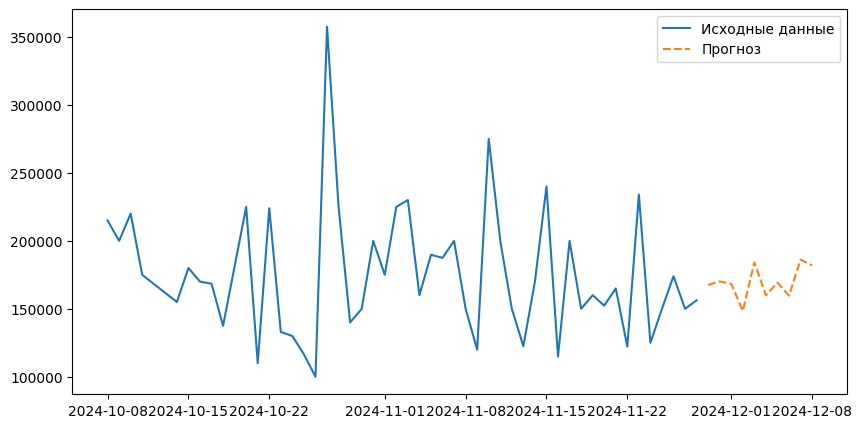

In [93]:
forecast_steps = 10
forecast = model_res.forecast(steps=forecast_steps)

plt.figure(figsize=(10, 5))
plt.plot(df_2.index, df_2, label="Исходные данные")
plt.plot(pd.date_range(df_2.index[-1], periods=forecast_steps+1, freq="D")[1:], forecast, label="Прогноз", linestyle="dashed")
plt.legend()
plt.show()

In [101]:
from sklearn.metrics import mean_squared_error
import numpy as np

actual = df_2[-forecast_steps:]  # Если у вас есть реальные данные для сравнения
rmse = np.sqrt(mean_squared_error(actual, forecast[:len(actual)]))
mean_value = df_2.mean()
std_dev = df_2.std()

print(f"RMSE: {rmse}")
print(f"Среднее значение ряда: {mean_value}")
print(f"Относительная ошибка: {rmse / mean_value:.2%}")
print(f"Стандартное отклонение ряда: {std_dev}")

RMSE: 27057.968776852023
Среднее значение ряда: 174841.5673076923
Относительная ошибка: 15.48%
Стандартное отклонение ряда: 46730.343591620585
